In [1]:
pip install --upgrade ipywidgets jupyterlab_widgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.4/214.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 49.1 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.9
    Uninstalling widgetsnbextension-3.6.9:
      Successfully uninstalled widgetsnbextension-3.6.9
  Attempting uninstall: jupyterlab_widgets
    Found existing installation: jupyterlab_widgets 3.0.11
    Uninstalling jupyterlab_widgets-3.0.11:
      Successfully uninstalled jupyterlab_widgets-3.0.11
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 0.22.0

In [2]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

class SinhalaGrammarDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize the text
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def prepare_dataset(csv_path):
    # Load dataset
    df = pd.read_csv(csv_path)
    
    # Convert labels to binary (correct=1, incorrect=0)
    df['binary_label'] = (df['label'] == 'correct').astype(int)
    
    # Split dataset
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        df['sentence'].values,
        df['binary_label'].values,
        test_size=0.2,
        random_state=42
    )
    
    return train_texts, val_texts, train_labels, val_labels

In [3]:
import re

def clean_sinhala_text_advanced(text):
    # Remove all zero-width characters and other control characters
    pattern = re.compile(u"[\u200B\u200C\u200D\u200E\u200F\u202A-\u202F\u2060-\u2069]")
    cleaned_text = pattern.sub("", text)
    return cleaned_text

In [4]:
import unicodedata

# Clean the string by removing zero-width spaces
def clean_string(text):
    return ''.join(c for c in text if not unicodedata.category(c).startswith('Cf'))


In [5]:
import torch
from torch import nn
from transformers import AutoTokenizer, AutoModel, AdamW
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
from tqdm import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Constants
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 1e-5

In [6]:
class SinhalaGrammarDataset(Dataset):
    def __init__(self, texts, labels, rules, tokenizer):
        self.texts = texts
        self.labels = labels
        self.rules = rules
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        rule = self.rules[idx]

        encoding = self.tokenizer(
            text,
            max_length=MAX_LENGTH,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(1 if label == 'correct' else 0, dtype=torch.long),
            'rule': torch.tensor(rule-1, dtype=torch.long)
        }

In [7]:
class SinhalaGrammarChecker(nn.Module):
    def __init__(self, sinbert_model, num_rules=5):
        super().__init__()
        self.sinbert = sinbert_model
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(768, 2)  # Binary classification
        self.rule_classifier = nn.Linear(768, num_rules)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.sinbert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # Use [CLS] token
        pooled_output = self.dropout(pooled_output)
        
        # Grammar correctness classification
        correctness_logits = self.classifier(pooled_output)
        # Rule classification
        rule_logits = self.rule_classifier(pooled_output)
        
        return correctness_logits, rule_logits

In [8]:
def prepare_data(csv_path):
    # Load data
    df = pd.read_csv(csv_path)
    
    # Initialize tokenizer
    tokenizer = AutoTokenizer.from_pretrained('NLPC-UOM/SinBERT-small')
    
    # Create dataset
    dataset = SinhalaGrammarDataset(
        df['sentence'].values,
        df['label'].values,
        df['rule'].values,
        tokenizer
    )
    
    # Create data loader
    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )
    
    return dataloader, tokenizer

# Load training and testing data
train_dataloader, tokenizer = prepare_data('/kaggle/input/mixdata/output-2 (4).csv')
test_dataloader, _ = prepare_data('/kaggle/input/mixdata/output-2 (4).csv')

config.json:   0%|          | 0.00/635 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/839k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/639k [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [9]:
def train_model(model, train_dataloader, test_dataloader, num_epochs):
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    
    model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for batch in tqdm(train_dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            rules = batch['rule'].to(device)
            
            optimizer.zero_grad()
            
            correctness_logits, rule_logits = model(input_ids, attention_mask)
            
            loss_correctness = criterion(correctness_logits, labels)
            loss_rules = criterion(rule_logits, rules)
            loss = loss_correctness + loss_rules
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_dataloader)
        print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}')
        
        # Evaluate on test set
        evaluate_model(model, test_dataloader, num_classes=2)

In [10]:
from torchmetrics import Accuracy, Precision, Recall, F1Score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

def evaluate_model(model, dataloader, num_classes):
    model.eval()
    
    # Initialize metrics
    accuracy = Accuracy(task="multiclass", num_classes=num_classes).to(device)
    precision = Precision(task="multiclass", num_classes=num_classes, average='macro').to(device)
    recall = Recall(task="multiclass", num_classes=num_classes, average='macro').to(device)
    f1 = F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device)
    
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            correctness_logits, _ = model(input_ids, attention_mask)
            predictions = torch.argmax(correctness_logits, dim=1)
            
            # Update metrics
            accuracy.update(predictions, labels)
            precision.update(predictions, labels)
            recall.update(predictions, labels)
            f1.update(predictions, labels)
            
            # Store predictions and labels for confusion matrix
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Compute final metrics
    acc = accuracy.compute()
    prec = precision.compute()
    rec = recall.compute()
    f1_score = f1.compute()
    
    # Reset metrics
    accuracy.reset()
    precision.reset()
    recall.reset()
    f1.reset()
    
    # Print metrics
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall: {rec:.4f}')
    print(f'F1 Score: {f1_score:.4f}')
    
    # Create metrics bar plot
    metrics = {
        'Accuracy': acc.item(),
        'Precision': prec.item(),
        'Recall': rec.item(),
        'F1 Score': f1_score.item()
    }
    
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Metrics Bar Chart
    plt.subplot(1, 2, 1)
    categories = list(metrics.keys())
    values = list(metrics.values())
    plt.bar(categories, values, color=['blue', 'orange', 'green', 'red'])
    plt.ylim(0, 1)
    plt.title('Model Evaluation Metrics')
    plt.xlabel('Metrics')
    plt.ylabel('Scores')
    plt.grid(axis='y')
    plt.axhline(y=0.5, color='grey', linestyle='--')
    
    # Plot 2: Confusion Matrix
    plt.subplot(1, 2, 2)
    conf_matrix = confusion_matrix(all_labels, all_predictions)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Class {i}' for i in range(num_classes)],
                yticklabels=[f'Class {i}' for i in range(num_classes)])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    
    plt.tight_layout()
    plt.show()
    
    return metrics

In [11]:
def is_purwa_kriya(sentence):
    # Common purwa kriya endings in Sinhala
    purwa_kriya_endings = [
        clean_string('ා'),    # Example: කා (having eaten)
        clean_string('ී'),    # Example: බී (having drunk)
        clean_string('ලා'),   # Example: ගිහිල්ලා (having gone)
        clean_string('න'),    # Example: කියන (saying)
        clean_string('ගෙන'),   # Example: අරගෙන (having taken)
        clean_string('ක​ර'),
        clean_string('ස්'),
        clean_string('​ණ'),
        clean_string('​වා'),
        clean_string('ස'),
        clean_string('ප'),
        clean_string('​සා'),
        clean_string('ඳී'),
        clean_string('​නු'),
        clean_string('න්'),
        clean_string('මින්'),
        clean_string('ගෙන'),
        clean_string('නට'),  
        clean_string('​ය'),      #ලියලි​ය
        clean_string('න්නේ')      
        
    ]
    
   # Split the sentence into words
    words = sentence.split()
     # Get the word before ඇත/නැත
    word_before_last = words[-2]
    # Check word_before_last (as purwa kriya comes before final action)
    for word in words[:-1]:
        for ending in purwa_kriya_endings:
            if word_before_last.endswith(ending):
                return True
    
    return False

In [12]:
def check_first_word_ending(sentence):
    # Define the endings in three priority groups
    priority_1_endings = [
        clean_string('සුන්'),
        clean_string('තී​න්'),
        clean_string('තී​හු'),
        clean_string('තූ​න්'),
        clean_string('තූ​හු'),
        clean_string('නෙ​කු​න්'),
        clean_string('නෙ​​ක්'),
        clean_string('මයින්'),
        clean_string('වන්'),
        clean_string('යින්'),
        clean_string('යන්'),
        clean_string('ව්රුන්'),
        clean_string('වු​රු'),
        clean_string('රුන්'),
        clean_string('වක්'),
        clean_string('මු​න්'),
        clean_string('ම්​හු'),
        clean_string('​මා'),
        clean_string('​ම​ම'),
        clean_string('​අ​ප'),
        clean_string('​අ​පි'),
        clean_string('​​තා'),
        clean_string('​​තෝ'),
        clean_string('​තො​ප'),
        clean_string('​තෙ​පි'),
        clean_string('​ඕ'),
        clean_string('​ඕ තොමෝ'),
        clean_string('​​ඈ'),
        clean_string('ය​ක'),
        clean_string('යක්')
        
    ]
    
    priority_2_endings = [
        clean_string('ස්සු'),
        clean_string('මයි'),
        clean_string('වෝ'),
        clean_string('යෝ'),
        clean_string('රු'),
        clean_string('යින්'),
        clean_string('නක්')
    ]
    
    priority_3_endings = [
        clean_string('න්'),
        clean_string('කු'),
        clean_string('ෝ'),
        clean_string('වක'),
        clean_string('නක'),
        clean_string('ක්'),
        clean_string('ක')
    ]
    
    # Get the first word of the sentence
    words = sentence.strip().split()
    if not words:  # If sentence is empty
        return None
    
    first_word = words[0].strip()
    
    # Remove zero-width characters
    first_word = first_word.replace('\u200b', '').replace('\u200c', '').replace('\u200d', '').replace('\ufeff', '')
    
    # Function to check endings with proper character handling
    def check_ending(word, ending):
        if len(word) < len(ending):
            return False
        word_chars = [c for c in word]
        ending_chars = [c for c in ending]
        return word_chars[-len(ending_chars):] == ending_chars
    
    # Check priority 1 endings first
    for ending in priority_1_endings:
        if check_ending(first_word, ending):
            return ending
    
    # If no priority 1 ending found, check priority 2
    for ending in priority_2_endings:
        if check_ending(first_word, ending):
            return ending
    
    # If no priority 2 ending found, check priority 3
    for ending in priority_3_endings:
        if check_ending(first_word, ending):
            return ending
            
    return None

In [13]:
def check_last_word_ending(sentence):
    # Define the endings in three priority groups
    priority_1_endings = [
        clean_string('සුන්'),
        clean_string('තී​න්'),
        clean_string('තී​හු'),
        clean_string('තූ​න්'),
        clean_string('තූ​හු'),
        clean_string('නෙ​කු​න්'),
        clean_string('නෙ​​ක්'),
        clean_string('මයින්'),
        clean_string('වන්'),
        clean_string('යින්'),
        clean_string('යන්'),
        clean_string('ව්රුන්'),
        clean_string('වු​රු'),
        clean_string('රුන්'),
        clean_string('වක්'),
        clean_string('මු​න්'),
        clean_string('ම්​හු'),
        clean_string('​මා'),
        clean_string('​ම​ම'),
        clean_string('​අ​ප'),
        clean_string('​අ​පි'),
        clean_string('​​තා'),
        clean_string('​​තෝ'),
        clean_string('​තො​ප'),
        clean_string('​තෙ​පි'),
        clean_string('​ඕ'),
        clean_string('​ඕ තොමෝ'),
        clean_string('​​ඈ'),
        clean_string('ය​ක'),
        clean_string('යක්')
        
    ]
    
    priority_2_endings = [
        clean_string('ස්සු'),
        clean_string('මයි'),
        clean_string('වෝ'),
        clean_string('යෝ'),
        clean_string('රු'),
        clean_string('යින්'),
        clean_string('නක්')
    ]
    
    priority_3_endings = [
        clean_string('න්'),
        clean_string('කු'),
        clean_string('ෝ'),
        clean_string('වක'),
        clean_string('නක'),
        clean_string('ක්'),
        clean_string('ක')
    ]
    
    # Get the first word of the sentence
    words = sentence.strip().split()
    if not words:  # If sentence is empty
        return None
    
    first_word = words[-1].strip()
    
    # Remove zero-width characters
    first_word = first_word.replace('\u200b', '').replace('\u200c', '').replace('\u200d', '').replace('\ufeff', '')
    
    # Function to check endings with proper character handling
    def check_ending(word, ending):
        if len(word) < len(ending):
            return False
        word_chars = [c for c in word]
        ending_chars = [c for c in ending]
        return word_chars[-len(ending_chars):] == ending_chars
    
    # Check priority 1 endings first
    for ending in priority_1_endings:
        if check_ending(first_word, ending):
            return ending
    
    # If no priority 1 ending found, check priority 2
    for ending in priority_2_endings:
        if check_ending(first_word, ending):
            return ending
    
    # If no priority 2 ending found, check priority 3
    for ending in priority_3_endings:
        if check_ending(first_word, ending):
            return ending
            
    return None

In [14]:
def check_before_last_word_ending(sentence):
    # Define the endings in three priority groups
    priority_1_endings = [
        clean_string('සුන්'),
        clean_string('තී​න්'),
        clean_string('තී​හු'),
        clean_string('තූ​න්'),
        clean_string('තූ​හු'),
        clean_string('නෙ​කු​න්'),
        clean_string('නෙ​​ක්'),
        clean_string('මයින්'),
        clean_string('වන්'),
        clean_string('යින්'),
        clean_string('යන්'),
        clean_string('ව්රුන්'),
        clean_string('වු​රු'),
        clean_string('රුන්'),
        clean_string('වක්'),
        clean_string('මු​න්'),
        clean_string('ම්​හු'),
        clean_string('​මා'),
        clean_string('​ම​ම'),
        clean_string('​අ​ප'),
        clean_string('​අ​පි'),
        clean_string('​​තා'),
        clean_string('​​තෝ'),
        clean_string('​තො​ප'),
        clean_string('​තෙ​පි'),
        clean_string('​ඕ'),
        clean_string('​ඕ තොමෝ'),
        clean_string('​​ඈ'),
        clean_string('ය​ක'),
        clean_string('යක්')
        
    ]
    
    priority_2_endings = [
        clean_string('ස්සු'),
        clean_string('මයි'),
        clean_string('වෝ'),
        clean_string('යෝ'),
        clean_string('රු'),
        clean_string('යින්'),
        clean_string('නක්')
    ]
    
    priority_3_endings = [
        clean_string('න්'),
        clean_string('කු'),
        clean_string('ෝ'),
        clean_string('වක'),
        clean_string('නක'),
        clean_string('ක්'),
        clean_string('ක')
    ]
    
    # Get the first word of the sentence
    words = sentence.strip().split()
    if not words:  # If sentence is empty
        return None
    
    first_word = words[-2].strip()
    
    # Remove zero-width characters
    first_word = first_word.replace('\u200b', '').replace('\u200c', '').replace('\u200d', '').replace('\ufeff', '')
    
    # Function to check endings with proper character handling
    def check_ending(word, ending):
        if len(word) < len(ending):
            return False
        word_chars = [c for c in word]
        ending_chars = [c for c in ending]
        return word_chars[-len(ending_chars):] == ending_chars
    
    # Check priority 1 endings first
    for ending in priority_1_endings:
        if check_ending(first_word, ending):
            return ending
    
    # If no priority 1 ending found, check priority 2
    for ending in priority_2_endings:
        if check_ending(first_word, ending):
            return ending
    
    # If no priority 2 ending found, check priority 3
    for ending in priority_3_endings:
        if check_ending(first_word, ending):
            return ending
            
    return None

In [15]:
def convert_n_to_o(sentence):

    # Get the first word of the sentence
    words = sentence.strip().split()
    if not words:  # If sentence is empty
        return None
    
    first_word = words[0]
    
    if first_word.endswith(clean_string('න්')):
        # Remove the 'න්' ending
        base_word = first_word[:-2]  # Remove last two characters ('න්')
        base_word = base_word.replace('\u200b', '').replace('\u200c', '').replace('\u200d', '').replace('\ufeff', '')
        
        # Add 'ෝ' ending
        return base_word + 'ෝ'
    return first_word

In [16]:
def convert_o_to_n(sentence):

    # Get the first word of the sentence
    words = sentence.strip().split()
    if not words:  # If sentence is empty
        return None
    
    first_word = words[0]
    
    if first_word.endswith(clean_string('ෝ')):
        # Remove the 'ෝ' ending
        base_word = first_word[:-1]  # Remove last two characters ('ෝ')
        base_word = base_word.replace('\u200b', '').replace('\u200c', '').replace('\u200d', '').replace('\ufeff', '')
        
        # Add '​න්' ending
        return base_word + '​න්'
    return first_word

In [17]:
def correct_grammar(model, tokenizer, sentence, rule_num):
    model.eval()
    print('ggggggggggggggggggggggggggggg1')
    # Tokenize input
    encoding = tokenizer(
        sentence,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        correctness_logits, rule_logits = model(input_ids, attention_mask)
        is_correct = torch.argmax(correctness_logits, dim=1).item() == 1
        
        result = {
            'original': sentence,
            'rule': rule_num,
            'is_correct': is_correct,
            'corrected': None,
            'message': ''
        }
        
        if not is_correct:
            print('ggggggggggggggggggggggggggggg2')
            # Correction logic here based on the rule 1
            if ((rule_num == 1) and (is_purwa_kriya(sentence)== False)):

                 print('ggggggggggggggggggggggggggggg4')
                
                 print(is_purwa_kriya(sentence))
                 print("නැත" in sentence or "ඇත" in sentence)
                 print("අ​ප" in sentence)
                 print('ggg')
                 print("තො​ප" in sentence)
                 print("අප" in sentence and "ඇත" in sentence and (is_purwa_kriya(sentence)== False))
                 print("තො​ප" in sentence)
                 print("ඇත" in sentence )
                 print((is_purwa_kriya(sentence)== False))
                 print('ggg')
                
            #පූර්ව ක්‍රියාවක් නොයෙදෙන සාමා​න්‍ය අවස්​තා
                 if (check_first_word_ending(sentence) == clean_string("මා")) and (("නැත" in sentence) or ("ඇත" in sentence)) :
                    result['corrected'] = sentence.replace(clean_string('මා'), 'මම')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ 'මා' යෙදීම වැරදියි. 'මම' යෙදිය යුතුයි."
                 
                 elif (check_first_word_ending(sentence) == clean_string("අ​ප")) and (("නැත" in sentence) or ("ඇත" in sentence)):
                   
                    result['corrected'] = sentence.replace(clean_string('අප'),'අපි')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ 'අ​ප' යෙදීම වැරදියි. 'අ​පි' යෙදිය යුතුයි."
                
                 elif (check_first_word_ending(sentence) == clean_string("​තා")) and (("නැත" in sentence) or ("ඇත" in sentence)) :
                    result['corrected'] = sentence.replace(clean_string("​තා"), '​තෝ')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත 'තා' යෙදීම වැරදියි. උක්ත 'තෝ' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("තො​ප")) and (("නැත" in sentence) or ("ඇත" in sentence)) :
                    result['corrected'] = sentence.replace(clean_string("​තො​ප"), '​තෙපි')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත 'තොප' යෙදීම වැරදියි. උක්ත 'තෙපි' යෙදිය යුතුයි."
                 elif clean_string("​ඔවු​න්") in sentence and (("නැත" in sentence) or ("ඇත" in sentence)) :
                    result['corrected'] = sentence.replace(clean_string('ඔවු​න්'), 'ඔවු​හු​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත 'ඔවු​න්' යෙදීම වැරදියි. උක්ත 'ඔවු​හු' යෙදිය යුතුයි."
                 elif clean_string("​ඇ​ය") in sentence and (("නැත" in sentence) or ("ඇත" in sentence)) :
                    result['corrected'] = sentence.replace(clean_string("​ඇ​ය"), '​ඕ/ඕ තොමෝ/ඈ')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත 'ඇ​ය' යෙදීම වැරදියි. උක්ත 'ඕ/ඕ තොමෝ/ඈ' යෙදිය යුතුයි."
            
                 elif (check_first_word_ending(sentence) == clean_string('සුන්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('gggggggggggggggggggggggggggggසු​බෘ1')
                    result['corrected'] = sentence.replace(clean_string('සුන්'), 'ස්සු')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි." 
                 elif (check_first_word_ending(sentence) == clean_string('මයින්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('gggggggggggggggggggggggggggggසු​බෘ2')
                    result['corrected'] = sentence.replace(clean_string('මයින්'),'ම​යි')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('වන්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('gggggggggggggggggggggggggggggසු​බෘ3')
                    result['corrected'] = sentence.replace(clean_string('වන්'), 'වෝ')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif ((check_first_word_ending(sentence) == clean_string('යි​න්')) or (check_first_word_ending(sentence) == 'යන්') ) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('gggggggggggggggggggggggggggggසු​බෘ4')
                    result['corrected'] = sentence.replace(clean_string('යි​න්'), '​යෝ')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('රුන්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('gggggggggggggggggggggggggggggසු​බෘ5')
                    result['corrected'] = sentence.replace(clean_string('රුන්'),'​රු')
                    print(result['corrected'])
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('න්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('gggggggggggggggggggggggggggggසු​බෘ6')
                    corrected_word = convert_n_to_o(sentence)
                    words = sentence.strip().split()
                    result['corrected'] = sentence.replace(words[0], corrected_word)
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."

                
                
                 elif (check_first_word_ending(sentence) == clean_string('​කු')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub1')
                    result['corrected'] = sentence.replace(clean_string('​කු'), '​​ක්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                     
                 elif (check_first_word_ending(sentence) == clean_string('​වක')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub2')
                    result['corrected'] = sentence.replace(clean_string('​වක'), '​​වක්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​නක')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub3')
                    result['corrected'] = sentence.replace(clean_string('​නක'), '​​නක්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​යක')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​යක'), '​​යක්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​ක')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​ක'), '​​ක්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."

                

                 elif (check_first_word_ending(sentence) == clean_string('​මු​න්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​මු​න්'), '​​ම්​හු')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​ව්රුන්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​ව්රුන්'), '​​වු​රු')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​නෙ​කු​න්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​නෙ​කු​න්'), '​​​නෙ​ක්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත 'කෙනෙකුන්' යෙදීම වැරදියි. උක්ත 'කෙනෙක්/කෙනෙකු' යෙදිය යුතුයි."

                
                 elif (check_first_word_ending(sentence) == clean_string('​තී​න්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​තී​න්'), '​​​තී​හු')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවචී රූප ගැන්වූ අප්‍රාණවචී නාමපද  ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත ක​තෲ යෙදීම වැරදියි. කතෲ උක්ත වි​ය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​තූ​න්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​තූ​න්'), '​​​තූ​හු')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවචී රූප ගැන්වූ අප්‍රාණවචී නාමපද  ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත ක​තෲ යෙදීම වැරදියි. කතෲ උක්ත වි​ය යුතුයි."
                    




                
            if ((rule_num == 2 or rule_num == 3) and is_purwa_kriya(sentence)):
                
            #පූර්ව ක්‍රියාවක් යෙදෙන අවස්​තා                
                 if (check_first_word_ending(sentence) == clean_string("ම​ම")) and "ඇත" in sentence :
                    result['corrected'] = sentence.replace(clean_string('මම'), 'මා')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ​ඇත්නම්, ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත 'මම' යෙදීම වැරදියි.  අනුක්ත කතෲ 'මා' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("ම​ම")) and "නැත" in sentence :
                    result['corrected'] = sentence.replace(clean_string('මම'), 'මා')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ​ඇත්නම්, ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත 'මම' යෙදීම වැරදියි. අනුක්ත කතෲ 'මා' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("අ​පි")) and "ඇත" in sentence :
                    result['corrected'] = sentence.replace(clean_string('අපි'), 'අප')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ​ඇත්නම්, ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත 'අපි' යෙදීම වැරදියි. අනුක්ත කතෲ 'අප' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("අ​පි")) and "නැත" in sentence :
                    result['corrected'] = sentence.replace(clean_string('අපි'), 'අප')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ​ඇත්නම්, ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත 'අපි' යෙදීම වැරදියි. අනුක්ත කතෲ 'අප' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("​තෝ")) and "නැත" in sentence :
                    result['corrected'] = sentence.replace(clean_string('​තෝ'), '​තා')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ​ඇත්නම්, ඇත/නැත ප්‍රත්‍යය සමඟ 'තෝ' යෙදීම වැරදියි. 'තා' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("තෙ​පි")) and "නැත" in sentence :
                    result['corrected'] = sentence.replace(clean_string('තෙ​පි'), 'තො​ප')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ​ඇත්නම්, ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත 'තෙ​පි' යෙදීම වැරදියි. අනුක්ත කතෲ 'තො​ප' යෙදිය යුතුයි."


                 elif clean_string("​ඔවු​හු​") in sentence and (("නැත" in sentence) or ("ඇත" in sentence)) and (is_purwa_kriya(sentence)) :
                    result['corrected'] = sentence.replace(clean_string('ඔවු​හු'), 'ඔවු​න්​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ ​උක්ත 'ඔවු​හු' යෙදීම වැරදියි. අනුක්​ත 'ඔවු​න්' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == ("​​ඕ") or check_first_word_ending(sentence) == clean_string("​​ඕ තොමෝ")  or check_first_word_ending(sentence) == clean_string("ඈ") ) and (("නැත" in sentence) or ("ඇත" in sentence)) :
                    result['corrected'] = sentence.replace(clean_string("​ඕ"), 'ඇ​ය​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ ​උක්ත 'ඕ/ඕ තොමෝ/ඈ' යෙදීම වැරදියි. අනුක්​ත 'ඇ​ය' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("​​ඕ තොමෝ") ) and (("නැත" in sentence) or ("ඇත" in sentence)) :
                    result['corrected'] = sentence.replace(clean_string("​ඕ තොමෝ"), 'ඇ​ය​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ ​උක්ත 'ඕ/ඕ තොමෝ/ඈ' යෙදීම වැරදියි. අනුක්​ත 'ඇ​ය' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("ඈ") ) and (("නැත" in sentence) or ("ඇත" in sentence)) :
                    result['corrected'] = sentence.replace(clean_string("​ඈ"), 'ඇ​ය​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ ​උක්ත 'ඕ/ඕ තොමෝ/ඈ' යෙදීම වැරදියි. අනුක්​ත 'ඇ​ය' යෙදිය යුතුයි."


                
                 elif (check_first_word_ending(sentence) == clean_string('ස්සු')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('gggggggggggggggggggggggggggggසු​බෘ1')
                    result['corrected'] = sentence.replace(clean_string('ස්සු'), 'සු​න්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි." 
                 elif (check_first_word_ending(sentence) == clean_string('ම​යි')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('gggggggggggggggggggggggggggggසු​බෘ2')
                    result['corrected'] = sentence.replace(clean_string('ම​යි'),'ම​යි​න්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('වෝ')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('gggggggggggggggggggggggggggggසු​බෘ3')
                    result['corrected'] = sentence.replace(clean_string('වෝ'), 'ව​න්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 elif ((check_first_word_ending(sentence) == clean_string('​යෝ')) or (check_first_word_ending(sentence) == 'යන්') ) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('gggggggggggggggggggggggggggggසු​බෘ4')
                    result['corrected'] = sentence.replace(clean_string('​යෝ'), '​යි​න්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('රු')) and ("නැත" in sentence or "ඇත" in sentence):
                    print('gggggggggggggggggggggggggggggසු​බෘ5')
                    result['corrected'] = sentence.replace(clean_string('රු'),'​රු​න්')
                    print(result['corrected'])
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('ෝ​')) and ("නැත" in sentence or "ඇත" in sentence):
                    print('gggggggggggggggggggggggggggggසු​බෘ6')
                    corrected_word = convert_o_to_n(sentence)
                    words = sentence.strip().split()
                    result['corrected'] = sentence.replace(words[0], corrected_word)
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."

                
                
                 
                 
                 elif (check_first_word_ending(sentence) == clean_string('​ය​ක්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​ය​ක්'), '​​යක')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 
                 elif (check_first_word_ending(sentence) == clean_string('​​​ක්')) and ("නැත" in sentence or "ඇත" in sentence):
                    print('ggggggggggggggggggggggggggggg-Sub1')
                    result['corrected'] = sentence.replace(clean_string('​​ක්'), '​​​කු')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                     
                 elif (check_first_word_ending(sentence) == clean_string('​ව​ක්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub2')
                    result['corrected'] = sentence.replace(clean_string('​ව​ක්'), '​​වක')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​න​ක්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub3')
                    result['corrected'] = sentence.replace(clean_string('​න​ක්'), '​​නක')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 

                

                 elif (check_first_word_ending(sentence) == clean_string('​​​ම්​හු')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('ම්​හු​'), 'මු​න්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන කතෲ අනුක්​ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​​වු​රු')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('වු​රු​'), 'ව්රුන්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන කතෲ අනුක්​ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​නෙ​ක්')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('නෙ​ක්​'), 'නෙ​කු​න්​​​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත කතෲ 'කෙනෙකුන්' යෙදීම වැරදියි. අනුක්​ත කතෲ 'කෙනෙක්/කෙනෙකු' යෙදිය යුතුයි."

                
                 elif (check_first_word_ending(sentence) == clean_string('​තී​හු')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('තී​හු'), '​තී​න්​​​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවචී රූප ගැන්වූ අප්‍රාණවචී නාමපද  ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත ක​තෲ යෙදීම වැරදියි. කතෲ අනුක්​ත වි​ය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​තූ​හු')) and ("නැත" in sentence or "ඇත" in sentence) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('තූ​හු'), '​තූ​න්​​​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවචී රූප ගැන්වූ අප්‍රාණවචී නාමපද  ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත ක​තෲ යෙදීම වැරදියි. කතෲ අනුක්​ත වි​ය යුතුයි."
                    
            if (rule_num == 4):
                

                 if (check_first_word_ending(sentence) == clean_string("මා"))  :
                    result['corrected'] = sentence.replace(clean_string('මා'), 'මම')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ 'මා' යෙදීම වැරදියි. 'මම' යෙදිය යුතුයි."
                 
                 elif (check_first_word_ending(sentence) == clean_string("අ​ප")) :
                   
                    result['corrected'] = sentence.replace(clean_string('අප'),'අපි')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ 'අ​ප' යෙදීම වැරදියි. 'අ​පි' යෙදිය යුතුයි."
                
                 elif (check_first_word_ending(sentence) == clean_string("​තා"))  :
                    result['corrected'] = sentence.replace(clean_string("​තා"), '​තෝ')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත 'තා' යෙදීම වැරදියි. උක්ත 'තෝ' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("තො​ප"))  :
                    result['corrected'] = sentence.replace(clean_string("​තො​ප"), '​තෙපි')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත 'තොප' යෙදීම වැරදියි. උක්ත 'තෙපි' යෙදිය යුතුයි."
                 elif clean_string("​ඔවු​න්") in sentence  :
                    result['corrected'] = sentence.replace(clean_string('ඔවු​න්'), 'ඔවු​හු​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත 'ඔවු​න්' යෙදීම වැරදියි. උක්ත 'ඔවු​හු' යෙදිය යුතුයි."
                 elif clean_string("​ඇ​ය") in sentence  :
                    result['corrected'] = sentence.replace(clean_string("​ඇ​ය"), '​ඕ/ඕ තොමෝ/ඈ')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත 'ඇ​ය' යෙදීම වැරදියි. උක්ත 'ඕ/ඕ තොමෝ/ඈ' යෙදිය යුතුයි."
            
                 elif (check_first_word_ending(sentence) == clean_string('සුන්')) or (check_before_last_word_ending == clean_string('සුන්')) :
                    print('gggggggggggggggggggggggggggggසු​බෘ1')
                    result['corrected'] = sentence.replace(clean_string('සුන්'), 'ස්සු')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි." 
                 elif (check_first_word_ending(sentence) == clean_string('මයින්')) or (check_before_last_word_ending == clean_string('මයින්')) :
                    print('gggggggggggggggggggggggggggggසු​බෘ2')
                    result['corrected'] = sentence.replace(clean_string('මයින්'),'ම​යි')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('වන්')) or (check_before_last_word_ending == clean_string('වන්')) :
                    print('gggggggggggggggggggggggggggggසු​බෘ3')
                    result['corrected'] = sentence.replace(clean_string('වන්'), 'වෝ')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif ((check_first_word_ending(sentence) == clean_string('යි​න්')) or (check_first_word_ending(sentence) == clean_string('යන්')) ) or (check_before_last_word_ending == clean_string('යන්') or check_before_last_word_ending == clean_string('යි​න්') ) :
                    print('gggggggggggggggggggggggggggggසු​බෘ4')
                    result['corrected'] = sentence.replace(clean_string('යි​න්'), '​යෝ')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('රුන්')) or (check_before_last_word_ending == clean_string('රුන්')) :
                    print('gggggggggggggggggggggggggggggසු​බෘ5')
                    result['corrected'] = sentence.replace(clean_string('රුන්'),'​රු')
                    print(result['corrected'])
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('න්')) or (check_before_last_word_ending == clean_string('න්')) :
                    print('gggggggggggggggggggggggggggggසු​බෘ6')
                    corrected_word = convert_n_to_o(sentence)
                    words = sentence.strip().split()
                    result['corrected'] = sentence.replace(words[0], corrected_word)
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."

                
                
                 elif (check_first_word_ending(sentence) == clean_string('​කු')) or (check_before_last_word_ending == clean_string('​කු')) :
                    print('ggggggggggggggggggggggggggggg-Sub1')
                    result['corrected'] = sentence.replace(clean_string('​කු'), '​​ක්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                     
                 elif (check_first_word_ending(sentence) == clean_string('​වක')) or (check_before_last_word_ending == clean_string('​වක')) :
                    print('ggggggggggggggggggggggggggggg-Sub2')
                    result['corrected'] = sentence.replace(clean_string('​වක'), '​​වක්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​නක')) or (check_before_last_word_ending == clean_string('​නක')) :
                    print('ggggggggggggggggggggggggggggg-Sub3')
                    result['corrected'] = sentence.replace(clean_string('​නක'), '​​නක්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​යක')) or (check_before_last_word_ending == clean_string('​යක')) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​යක'), '​​යක්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​ක')) or (check_before_last_word_ending == clean_string('​ක')) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​ක'), '​​ක්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ උක්ත විය යුතුයි."

                

                 elif (check_first_word_ending(sentence) == clean_string('​මු​න්')) or (check_before_last_word_ending == clean_string('​මු​න්')) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​මු​න්'), '​​ම්​හු')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​ව්රුන්')) or (check_before_last_word_ending == clean_string('​ව්රුන්')) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​ව්රුන්'), '​​වු​රු')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන කතෲ උක්ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​නෙ​කු​න්')) or (check_before_last_word_ending == clean_string('​නෙ​කු​න්')) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​නෙ​කු​න්'), '​​​නෙ​ක්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත 'කෙනෙකුන්' යෙදීම වැරදියි. උක්ත 'කෙනෙක්/කෙනෙකු' යෙදිය යුතුයි."

                
                 elif (check_first_word_ending(sentence) == clean_string('​තී​න්')) or (check_before_last_word_ending == clean_string('​තී​න්')) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​තී​න්'), '​​​තී​හු')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවචී රූප ගැන්වූ අප්‍රාණවචී නාමපද  ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත ක​තෲ යෙදීම වැරදියි. කතෲ උක්ත වි​ය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​තූ​න්')) or (check_before_last_word_ending == clean_string('​තූ​න්')) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​තූ​න්'), '​​​තූ​හු')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවචී රූප ගැන්වූ අප්‍රාණවචී නාමපද  ඇති විට, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ අනුක්ත ක​තෲ යෙදීම වැරදියි. කතෲ උක්ත වි​ය යුතුයි."

            if (rule_num == 5):
                
                 if (check_first_word_ending(sentence) == clean_string("ම​ම"))  :
                    result['corrected'] = sentence.replace(clean_string('මම'), 'මා')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ​ඇත්නම්, ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත 'මම' යෙදීම වැරදියි.  අනුක්ත කතෲ 'මා' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("ම​ම"))  :
                    result['corrected'] = sentence.replace(clean_string('මම'), 'මා')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ​ඇත්නම්, ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත 'මම' යෙදීම වැරදියි. අනුක්ත කතෲ 'මා' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("අ​පි")) :
                    result['corrected'] = sentence.replace(clean_string('අපි'), 'අප')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ​ඇත්නම්, ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත 'අපි' යෙදීම වැරදියි. අනුක්ත කතෲ 'අප' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("අ​පි")) :
                    result['corrected'] = sentence.replace(clean_string('අපි'), 'අප')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ​ඇත්නම්, ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත 'අපි' යෙදීම වැරදියි. අනුක්ත කතෲ 'අප' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("​තෝ"))  :
                    result['corrected'] = sentence.replace(clean_string('​තෝ'), '​තා')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ​ඇත්නම්, ඇත/නැත ප්‍රත්‍යය සමඟ 'තෝ' යෙදීම වැරදියි. 'තා' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("තෙ​පි"))  :
                    result['corrected'] = sentence.replace(clean_string('තෙ​පි'), 'තො​ප')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ​ඇත්නම්, ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත 'තෙ​පි' යෙදීම වැරදියි. අනුක්ත කතෲ 'තො​ප' යෙදිය යුතුයි."


                 elif check_first_word_ending(sentence) == clean_string("​​ඔවු​හු") in sentence  :
                    result['corrected'] = sentence.replace(clean_string('ඔවු​හු'), 'ඔවු​න්​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ ​උක්ත 'ඔවු​හු' යෙදීම වැරදියි. අනුක්​ත 'ඔවු​න්' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == ("​​ඕ") or check_first_word_ending(sentence) == clean_string("​​ඕ තොමෝ")  or check_first_word_ending(sentence) == clean_string("ඈ") )  :
                    result['corrected'] = sentence.replace(clean_string("​ඕ"), 'ඇ​ය​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ ​උක්ත 'ඕ/ඕ තොමෝ/ඈ' යෙදීම වැරදියි. අනුක්​ත 'ඇ​ය' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("​​ඕ තොමෝ") )  :
                    result['corrected'] = sentence.replace(clean_string("​ඕ තොමෝ"), 'ඇ​ය​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ ​උක්ත 'ඕ/ඕ තොමෝ/ඈ' යෙදීම වැරදියි. අනුක්​ත 'ඇ​ය' යෙදිය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string("ඈ") )  :
                    result['corrected'] = sentence.replace(clean_string("​ඈ"), 'ඇ​ය​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ ​උක්ත 'ඕ/ඕ තොමෝ/ඈ' යෙදීම වැරදියි. අනුක්​ත 'ඇ​ය' යෙදිය යුතුයි."


                
                 elif (check_first_word_ending(sentence) == clean_string('ස්සු'))  :
                    print('gggggggggggggggggggggggggggggසු​බෘ1')
                    result['corrected'] = sentence.replace(clean_string('ස්සු'), 'සු​න්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි." 
                 elif (check_first_word_ending(sentence) == clean_string('ම​යි'))  :
                    print('gggggggggggggggggggggggggggggසු​බෘ2')
                    result['corrected'] = sentence.replace(clean_string('ම​යි'),'ම​යි​න්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('වෝ'))  :
                    print('gggggggggggggggggggggggggggggසු​බෘ3')
                    result['corrected'] = sentence.replace(clean_string('වෝ'), 'ව​න්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 elif ((check_first_word_ending(sentence) == clean_string('​යෝ')) or (check_first_word_ending(sentence) == 'යන්') ) :
                    print('gggggggggggggggggggggggggggggසු​බෘ4')
                    result['corrected'] = sentence.replace(clean_string('​යෝ'), '​යි​න්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('රු')) :
                    print('gggggggggggggggggggggggggggggසු​බෘ5')
                    result['corrected'] = sentence.replace(clean_string('රු'),'​රු​න්')
                    print(result['corrected'])
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('ෝ​')) :
                    print('gggggggggggggggggggggggggggggසු​බෘ6')
                    corrected_word = convert_o_to_n(sentence)
                    words = sentence.strip().split()
                    result['corrected'] = sentence.replace(words[0], corrected_word)
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."

                
                
                 
                 
                 elif (check_first_word_ending(sentence) == clean_string('​ය​ක්'))  :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('​ය​ක්'), '​​යක')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 
                 elif (check_first_word_ending(sentence) == clean_string('​​​ක්')) :
                    print('ggggggggggggggggggggggggggggg-Sub1')
                    result['corrected'] = sentence.replace(clean_string('​​ක්'), '​​​කු')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                     
                 elif (check_first_word_ending(sentence) == clean_string('​ව​ක්'))  :
                    print('ggggggggggggggggggggggggggggg-Sub2')
                    result['corrected'] = sentence.replace(clean_string('​ව​ක්'), '​​වක')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​න​ක්'))  :
                    print('ggggggggggggggggggggggggggggg-Sub3')
                    result['corrected'] = sentence.replace(clean_string('​න​ක්'), '​​නක')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි."
                 

                

                 elif (check_first_word_ending(sentence) == clean_string('​​​ම්​හු'))  :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('ම්​හු​'), 'මු​න්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන කතෲ අනුක්​ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​​වු​රු'))  :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('වු​රු​'), 'ව්රුන්')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන කතෲ අනුක්​ත විය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​නෙ​ක්'))  :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('නෙ​ක්​'), 'නෙ​කු​න්​​​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත කතෲ 'කෙනෙකුන්' යෙදීම වැරදියි. අනුක්​ත කතෲ 'කෙනෙක්/කෙනෙකු' යෙදිය යුතුයි."

                
                 elif (check_first_word_ending(sentence) == clean_string('​තී​හු'))  :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('තී​හු'), '​තී​න්​​​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවචී රූප ගැන්වූ අප්‍රාණවචී නාමපද  ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත ක​තෲ යෙදීම වැරදියි. කතෲ අනුක්​ත වි​ය යුතුයි."
                 elif (check_first_word_ending(sentence) == clean_string('​තූ​හු')) :
                    print('ggggggggggggggggggggggggggggg-Sub4')
                    result['corrected'] = sentence.replace(clean_string('තූ​හු'), '​තූ​න්​​​')
                    result['message'] = "කතෲ ලෙස ප්‍රාණවචී රූප ගැන්වූ අප්‍රාණවචී නාමපද  ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ උක්ත ක​තෲ යෙදීම වැරදියි. කතෲ අනුක්​ත වි​ය යුතුයි."


                 print('ggggggggggggggggggggggggggggg6')
        
        # Add more rule-specific corrections
        
        return result

In [18]:
!pip install openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.0/345.0 kB 25.8 MB/s eta 0:00:00


In [19]:
from openai import OpenAI
import pandas as pd

class SinhalaGrammarCheckerWithLlma:
    def __init__(self, api_key):
        self.client = OpenAI(
            api_key=api_key,
            base_url="https://api.perplexity.ai"
        )
        
        # Define grammar rules dictionary
        self.grammar_rules = {
            "rule_1": {
                "name": "ඇත/නැත ප්‍රත්‍යයේ යෙදීම-01",
                "description": "ඇත/නැ​ත ලෙස වාක්‍යයක ආක්‍යාතය යෙදෙන විටදී, පූර්ව ක්‍රියාවක් වාක්‍යයේ නැති නම් වාක්‍යයේ කතෲ උක්ත වේ. කතෲ උක්ත වාක්‍ය පමණක් correct වේ. කතෲ අනුක්ත නම් වාක්‍යය incorrect වේ. කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට උක්ත අනුක්ත භේදය (උදා: මම-මා, අපි-අප, තෝ-තා, තෙපි-තොප, ඔබ-ඔබ, ඔහු-ඔහු, ඔවුහු-ඔවුන්, හේ/හෙතෙමෙ/හෙතෙමේ/හේ තෙමේ/- ඔහු, ඕ/ඕ තොමෝ - ඈ/ඇය), තවද ප්‍රාණවාචී බහුවචන පද ඇති විට උක්ත අනුක්ත භේදය (උදා: මිනිස්සු-මිනිසුන්, ළමයි-ළමයින්, කාන්තාවෝ-කාන්තාවන්, ගුරුවරු-ගුරුවරුන්, ගවයෝ-ගවයන්), ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට උක්ත අනුක්ත භේදය (උදා: මිනිසෙක්-මිනිසෙකු, ළමයෙක්-ළමයෙකු, ගුරුවරයෙක්-ගුරුවරයෙකු, කාන්තාවක්-කාන්තාවක, දෙනක්-දෙනක, නිළියක්-නිළියක, ගුරුවරියක්-ගුරුවරියක), ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට උක්ත අනුක්ත භේදය (ඇතැම්හු/ඇතැම්මු-ඇතැමුන්, සමහරු-සමහරුන්, කවුරු-කව්රුන්, ඇතැමෙක්-ඇතැමෙකු, සමහරෙක්-සමහරෙකු, යමෙක්-යමෙකු, කිසිවෙක්-කිසිවෙකු, අයෙක්-අයෙකු, කවරෙක්-කවරෙකු, කෙනෙක්-කෙනෙකු/කෙනෙකුන්), ප්‍රාණවචී රූප ගැන්වූ අප්‍රාණවචී නාමපද ඇති විට උක්ත අනුක්ත භේදය (උදා: ගංගාවෝ-ගංගාවන්, තාරකාවෝ-තාරකාවන්, රීතීහු-රීතීන්, හේතූහු-හේතූන්). මෙහි '-' මගින් උක්ත-අනුක්ත පද වෙන්කර දක්වා ඇත."
            },
            "rule_2": {
                "name": "ඇත/නැත ප්‍රත්‍යයේ යෙදීම-02",
                "description": "ඇත/නැ​ත ලෙස වාක්‍යයක ආක්‍යාතය යෙදෙන විටදී, පූර්ව ක්‍රියාවක් වාක්‍යයේ ​ඇති නම් වාක්‍යයේ කතෲ අනුක්​ත වේ. කතෲ අනුක්​ත වාක්‍ය පමණක් correct වේ. කතෲ ​උක්ත නම් වාක්‍යය incorrect වේ. කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම පද ඇති විට උක්ත අනුක්ත භේදය (උදා: මම-මා, අපි-අප, තෝ-තා, තෙපි-තොප, ඔබ-ඔබ, ඔහු-ඔහු, ඔවුහු-ඔවුන්, හේ/හෙතෙමෙ/හෙතෙමේ/හේ තෙමේ/- ඔහු, ඕ/ඕ තොමෝ - ඈ/ඇය), තවද ප්‍රාණවාචී බහුවචන පද ඇති විට උක්ත අනුක්ත භේදය (උදා: මිනිස්සු-මිනිසුන්, ළමයි-ළමයින්, කාන්තාවෝ-කාන්තාවන්, ගුරුවරු-ගුරුවරුන්, ගවයෝ-ගවයන්), ප්‍රාණවාචී අනියම් ඒකවචන පද ඇති විට උක්ත අනුක්ත භේදය (උදා: මිනිසෙක්-මිනිසෙකු, ළමයෙක්-ළමයෙකු, ගුරුවරයෙක්-ගුරුවරයෙකු, කාන්තාවක්-කාන්තාවක, දෙනක්-දෙනක, නිළියක්-නිළියක , ගුරුවරියක්-ගුරුවරියක), ප්‍රාණවාචී සර්වනාම සමූහාර්ත පද ඇති විට උක්ත අනුක්ත භේදය (ඇතැම්හු/ඇතැම්මු-ඇතැමුන්, සමහරු-සමහරුන්, කවුරු-කව්රුන්, ඇතැමෙක්-ඇතැමෙකු, සමහරෙක්-සමහරෙකු, යමෙක්-යමෙකු, කිසිවෙක්-කිසිවෙකු, අයෙක්-අයෙකු, කවරෙක්-කවරෙකු, කෙනෙක්-කෙනෙකු/කෙනෙකුන්), ප්‍රාණවචී රූප ගැන්වූ අප්‍රාණවචී නාමපද ඇති විට උක්ත අනුක්ත භේදය (උදා: ගංගාවෝ-ගංගාවන්, තාරකාවෝ-තාරකාවන්, රීතීහු-රීතීන්, හේතූහු-හේතූන්). මෙහි '-' මගින් උක්ත-අනුක්ත පද වෙන්කර දක්වා ඇත.මෙහිදී පූර්ර්ව ක්‍රියා වාක්‍ය​යේ ඇත්ත​ම් (උදා: ක​ර, බලා , පැමි​ණ, ආදී වූ විවිද පූ​ර්ව ක්‍රියා සියල්ල හදුනාගන්න) කතෲ අනුක්ත විය යුතුයි."
            # more grammar rules here
        },
            "rule_4": {
                "name": "(4): දිවිත්ව උක්තයේ යෙදීම",
                "description":"ද්විත්ව උක්තය යනු වාක්‍යයක කර්තෘ පද දෙකක් උක්ත ස්වරූපයෙන් යෙදී, ඒවාට පොදු වන බහුවචන ආඛ්‍යාතයක් යෙදීමයි. මෙහි ක්තෲ පද දෙකෙන්ම එකම පිරිසක් හැදින්විය/උක්ත විය යුතුය.වාක්‍යයේ කර්තෘ පද දෙකම උක්ත ස්වරූපයෙන් යෙදිය යුතුය.මෙම කර්තෘ පද දෙකන්ම එකම පුද්ගලයාහදුන්වන බව හැඟවිය යුතුය.ආඛ්‍යාත පදය - උක්ත පද දෙකටම පොදු වන බහුවචන ආඛ්‍යාතයක් යෙදිය යුතුය.මෙහි examples මගින් එක් වාක්‍යයක් ඇසුරින් සියලු correct සහ incorrect ආකාර දක්වා ඇත. ඒවා අධ්‍යනය කර test_sentences හි නිවැරදි වාක්‍යය නිවැරදිව predict කරන්න.",
                "examples": {
                    "correct": [
                        "දරුවෝ අනාගත පුරවැසියෝ ය.",
                        "දරුවෝ අනාගත පුරවැසියෝ වෙති.",
                        "දරුවෝ අනාගත පුරවැසියෝ වන්නෝය.",
                        "දරුවෝ අනාගත පුරවැසියෝ ද?",
                        "දරුවෝ අනාගත පුරවැසියෝ වේ.",
                        "දරුවෝ අනාගත පුරවැසියෝ විය.",
                        "දරුවෝ අනාගත පුරවැසියෝ ​ලු.",
                        "දරුවෝ අනාගත පුරවැසීහු වෙති.",
                        "දරූහු අනාගත පුරවැසීහු වෙති.",
                        "දරූහු අනාගත පුරවැසීහු ද?",
                        "දරූහු අනාගත පුරවැසීහු වේ.",
                        "දරූහු අනාගත පුරවැසීහු ය.",
                        "දරූහු අනාගත පුරවැසීහු විය.",
                        "දරූහු අනාගත පුරවැසීහු ලු.",
                        "දරූහු අනාගත පුරවැසීහු වන්නෝය.",
                        "දරූහු අනාගත පුරවැසීහු වන්​හ.",
                        "දරූහු අනාගත පුරවැසියෝ වෙති.",
                        "දරූහු අනාගත පුරවැසියෝ වන්නෝය.",
                        "දරූහු අනාගත පුරවැසියෝ ය.",
                        "දරූහු අනාගත පුරවැසියෝ ලු.",
                        "මම ගුරුවරයෙක් වෙමි.",
                        "අපි නායකයෝ වෙමු."
                    ],
                    "incorrect": [
                        "දරුවෝ අනාගත පුරවැසියන් ය.",
                        "දරුවන් අනාගත පුරවැසියෝ ය.",
                        "දරුවන් අනාගත පුරවැසිය​න් ය.",
                        "දරුවන් අනාගත පුරවැසියෝ වෙති.",
                        "දරුවෝ අනාගත පුරවැසියන් වෙති.",
                        "දරුවන් අනාගත පුරවැසියන් වෙති.",
                        "දරුවන් අනාගත පුරවැසියෝ වන්නෝය.",
                        "දරුවෝ අනාගත පුරවැසියන් වන්නෝය.",
                        "දරුවන් අනාගත පුරවැසියන් වන්නෝය.",
                        "දරුවෝ අනාගත පුරවැසියෝ වෙයි.",
                        "දරුවන් අනාගත පුරවැසියෝ වෙයි.",
                        "දරුවෝ අනාගත පුරවැසියන් වෙයි.",
                        "දරුවන් අනාගත පුරවැසියන් වෙයි.",
                        "දරුවන් අනාගත පුරවැසියෝ වන්නේය.",
                        "දරුවෝ අනාගත පුරවැසියන් වන්නේය.",
                        "දරුවන් අනාගත පුරවැසියන් වන්නේය.",
                        "දරුවෝ අනාගත පුරවැසියන් ද?",
                        "දරුවන් අනාගත පුරවැසියෝ ද?",
                        "දරුවන් අනාගත පුරවැසිය​න් ද?",
                        "දරුවන් අනාගත පුරවැසියෝ වේ.",
                        "දරුවන් අනාගත පුරවැසියන් වේ.",
                        "දරුවෝ අනාගත පුරවැසියන් වේ.",
                        "දරුවන් අනාගත පුරවැසියෝ වන්නීය.",
                        "දරුවන් අනාගත පුරවැසියන් වන්නීය.",
                        "දරුවෝ අනාගත පුරවැසියන් වන්නීය.",
                        "දරුවන් අනාගත පුරවැසියෝ වන්නීය.",
                        "දරුවන් අනාගත පුරවැසියෝ ලු.",
                        "දරුවෝ අනාගත පුරවැසියන් ලු.",
                        "දරුවන් අනාගත පුරවැසියන් ලු.",
                        "දරුවන් අනාගත පුරවැසීහු වෙති.",
                        "දරූහු අනාගත පුරවැසියන් වෙති.",
                        "දරුවන් අනාගත පුරවැසීහු වන්නෝය.",
                        "දරූහු අනාගත පුරවැසියන් වන්නෝය.",
                        "දරුවන් අනාගත පුරවැසීහු ද?",
                        "දරූහු අනාගත පුරවැසියන් ද?",
                        "දරූහු අනාගත පුරවැසියෝ ද?",
                        "දරුවන් අනාගත පුරවැසීහු වේ.",
                        "දරූහු අනාගත පුරවැසියන් වේ.",
                        "දරූහු අනාගත පුරවැසියෝ වේ.",
                        "දරුවන් අනාගත පුරවැසීහු ය.",
                        "දරූහු අනාගත පුරවැසියන් ය.",
                        "දරූහු අනාගත පුරවැසීහු වෙයි.",
                        "දරුවන් අනාගත පුරවැසීහු වෙයි.",
                        "දරූහු අනාගත පුරවැසියන් වෙයි.",
                        "දරූහු අනාගත පුරවැසියෝ වෙයි.",
                        "දරුවන් අනාගත පුරවැසීහු විය.",
                        "දරූහු අනාගත පුරවැසියන් විය.",
                        "දරූහු අනාගත පුරවැසියෝ විය.",
                        "දරූහු අනාගත පුරවැසීහු වන්නීය.",
                        "දරුවන් අනාගත පුරවැසීහු වන්නීය.",
                        "දරූහු අනාගත පුරවැසියන් වන්නීය.",
                        "දරූහු අනාගත පුරවැසියෝ වන්නීය.",
                        "දරුවන් අනාගත පුරවැසීහු ලු.",
                        "දරූහු අනාගත පුරවැසියන් ලු.",
                        "මා ගුරුවරයෙකු වෙමි."
                    ]
                    }         
                 },
            "rule_5": {
                "name": "(5): සින්හල වාක්‍ය තුල සන්ශය අර්තයේ ක්‍රියාවල යෙදීම",
                "description":"සින්හල වාක්‍ය තුල සන්ශය අර්තයේ ක්‍රියාවල යෙදීම.උදූ: මා පාඩම් කරති'යි අම්මා සිතුවාය. අතුරු වාක්‍යය සහ ප්‍රදාන වාක්‍යය ලෙස කොටස් දෙකකි.'​යි' යනු සම්බන්දක නිපාතයයි. අතුරු වාක්‍යයේ('යි'ට පෙර යෙදෙන වාක්‍යයේ ) අඛ්‍යාතය අනුක්ත හා ප්‍රත​ම පුරුෂ බහුවචනයෙන් තැබිය යුතුය. ප්‍රදාන වාක්‍යයේ('යි'ට පසුව යෙදෙන වාක්‍ය​යේ) කතෲ අනිවාර්යයෙන්ම උක්ත විය යුතු​ය. ආඛ්‍යාතය ලබාදෙන වාක්‍යය වර්තමාන කාලද, අතීත කාලද, අනාගත කාලද පිලිබද සලකා බලා,  එම ප්‍රදාන වාක්‍ය​යේ උක්තයට ගැළපෙන පරි​දි ආක්‍යාත​ය තැබිය යුතු​ය.   උදා: 1. වර්තමාන කාල​ය පිලිබද නිදසු​න්, ඔහු අද මෙහි එති'යි මම සිතීමි.,ගෙ වැසියන් නිදති'යි සොරු සිතූහ., තා ඒ ගමන නොයති'යි සිතා හේ දොම්නසට පත්විය.,තොප යුද වදිති'යි සතුරෝ බියට පත් වූහ.,මා ඒ මුදල් ආපසු නොදෙති'යි හේ බියට පත් විය.,අප වැඩ කරති'යි ප්‍රධානීහු බියට පත් වූහ.,සතුරන් අගනුවරට පහර දෙති'යි මග සෙනෙවියා රජුට දැන්වීය.(මෙහි සතුරන් කතෲ අනුක්ත ව් සිටින අතර දෙති යන ආක්‍යාතය ප්‍රතම පුරුෂ බහු වචනයෙන් තැබිය යුතුය.), 2.අතීත කාල​ය පිලිබද නිදසු​න්, අතීත කාලයේ වුවද ඉහත නීතියේ වෙනස​ක් නොවෙයි.අතුරු වාක්‍යය සහ ප්‍රදාන වාක්‍යය ලෙස කොටස් දෙකකි.යි යනු සම්බන්දක නිපාතයයි. අතුරු වාක්‍යයේ අඛ්‍යාතය අනුක්ත හා ප්‍රතම පුරුෂ බහුවචනයෙන් තැබිය යුතුය. ප්‍රදාන වාක්‍යයේ කතෲ උක්ත වේ. ආඛ්‍යාතය සාමාන්‍ය පරිදි වේ.උදා: ඔහු එහි ගියහ'යි හේ සිතීය.,සේවකයන් ආපසු වැඩට ගියහ'යි නිවේදකයා වාර්තා කලේය.,තා ගස කැපූහ'යි මම සිතී​මි.,තොප සැගවුනහ'යි අපි සිතමු., මා මළහ'යි තා සිතන්නට ඇත.,අප ඒ වැඩය නොකළහ'යි කළමනාකරු නිකරුණේ අපට දොස් නැගීය.,මේ අයුරින් වර්තමාන හා අතීත කාල දෙකටම අදාලව , විවිද උක්ත අනුක්ත පද යොදා , 'යි' සම්බන්දක නිපාතය යොදා, අතුරු වාක්‍යයේ අඛ්‍යාතය අනුක්ත හා ප්‍රතම පුරුෂ බහුවචනයෙන් යොදා, ප්‍රදාන වාක්‍යයේ කතෲ උක්ත වන පරිදි, එහි ආඛ්‍යාතය සාමාන්‍ය පරිදි තබා, මෙවැනි විවිධ උක්ත අනුක්ත පද අනුව මෙහි examples මගින් එක් වාක්‍යයක් ඇසුරින් සියලු correct සහ incorrect ආකාර දක්වා ඇත. ඒවා අධ්‍යනය කර test_sentences හි නිවැරදි වාක්‍යය නිවැරදිව predict කරන්න.සෑම විටම අතුරු වාක්‍යයේ ආඛ්‍යාතය ප්‍රථම පුරුෂ බහුවචනයෙන් පමණක් යෙදිය යුතුය.සින්හල වාක්‍ය තුල , කතෲ ලෙස ප්‍රාණවාචී සර්ව නාම උක්ත පද ඇති විට  - මම, අපි, තෝ, තෙපි, ඔබ, ඔහු,ඔවුහු, හේ/හෙතෙමෙ/හෙතෙමේ/හේ තෙමේ,  ඕ/ඕ තොමෝ  ,ප්‍රාණවාචී උක්ත බහුවචන පද ඇති විට - මිනිස්සු, ළමයි, කාන්තාවෝ, ගුරුවරු, ගවයෝ ආදී ​වූ,ප්‍රාණවාචී අනියම් ඒකවචන උක්ත පද ඇති විට , මිනිසෙක්, ළමයෙක්, ගුරුවරයෙක්, කාන්තාවක්, දෙනක්, නිළියක්, ගුරුවරියක් ආදී ​වූ,ප්‍රාණවාචී සර්වනාම සමූහාර්ත උක්ත පද  ඇති විට  , ඇතැම්හු/ඇතැම්මු, සමහරු, කවුරු, ඇතැමෙක්, සමහරෙක්, යමෙක්-යමෙකු, කිසිවෙක්, අයෙක්, කවරෙක්, කෙනෙක්  ආදී ​වූ,ප්‍රාණවචී රූප ගැන්වූ අප්‍රාණවචී උක්ත නාමපද  ඇති විට , උද: ග​​oගාවෝ, තාරකාවෝ, රීතීහු, හේතූහු  ආදී ​වූ ,මෙම ආකාර ගන්න උක්තපද ඇති විට 'යි' ට පසුව යෙදෙන ප්‍රදාන වාක්‍යයේ ආක්‍යාතය ඒ අනුව සකසන්න, ",
                "examples": {
                    "correct": [
                        "ඔහු අද මෙහි එති'යි මම සිතීමි.",
                        "ඔහු අද මෙහි එති'යි මම සිතමි.",
                        "ගෙ වැසියන් නිදති'යි අ​පි සිත​මු.",
                        "තා ඒ ගමන නොයති'යි සිතා හේ දොම්නසට පත්විය.",
                        "තොප යුද වදිති'යි සතුරෝ බියට පත් වූහ.",
                        "මා ඒ මුදල් ආපසු නොදෙති'යි හේ බියට පත් විය.",
                        "අප වැඩ කරති'යි ප්‍රධානීහු බියට පත් වූහ.",
                        "මිනිසුන් වැඩ කරති'යි සමිති නායකයෝ සිතූහ.",
                        "ගුරුවරුන් පන්තියට එති'යි විදුහල්පති සිතීය.",
                        "ඇතැමුන් ගෙදර යති'යි මම සිතුවෙමි.",
                        "කාන්තාවන් රැස්වීමට පැමිණෙති'යි ලේකම් දැනුම් දුන්නාය.",
                        "සමහරුන් විරුද්ධ වෙති'යි නායකයා බිය විය.",
                        "ග​න්ඟාවන් ගලති'යි වැසියෝ කීහ.",
                        "මා පාඩම් කරති'යි ඔහු සිතීය.",
                        "අප ගමන් කරති'යි තෙපි දුටුවහු.",
                        "තා පැමිණෙති'යි මම බලා සිටියෙමි.",
                        "තොප යති'යි ඔවුහු කල්පනා කළහ.",
                        "ඔහු ලියති'යි ඕ තොමෝ පැවසුවාය.",
                        "මිනිසුන් වැඩ කරති'යි ගුරුවරු දුටුවෝය.",
                        "ළමයින් සෙල්ලම් කරති'යි කාන්තාවෝ කීහ.",
                        "ගුරුවරුන් උගන්වති'යි සිසුහු පැවසූහ.",
                        "ගවයන් තණ කති'යි ගොවියෝ දුටුවෝය.",
                        "කාන්තාවන් රැස්වෙති'යි නායිකාවෝ දැන්වූහ.",
                        "ගුරුවරයෙකු පැමිණෙති'යි දරුවෝ බලා සිටියහ.",
                        "කාන්තාවක පැමිණෙති'යි නිළියක් පැවසුවාය.",
                        "ගුරුවරියක උගන්වති'යි දෙමව්පියෝ දැන සිටියහ.",
                        "දෙනක බිම වැතිරෙති'යි ගොවියෝ දුටුවෝය.",
                        "ඇතැමුන් නැගිටිති'යි සමහරු කීහ.",
                        "කව්රුන් එති'යි කෙනෙක් විමසීය.",
                        "යමෙකු පැමිණෙති'යි කිසිවෙක් නොකීවේය.",
                        "අයෙකු හමුවෙති'යි කවරෙක් හෝ පැවසීය.",
                        "කෙනෙකුන් එති'යි සමහරෙක් සිතුවේය.",
                        "ගංගාවන් ගලති'යි තාරකාවෝ බැලූහ.",
                        "රීතීන් වෙනස්වෙති'යි හේතූහු පෙන්වූහ.",
                        "තාරකාවන් දිලිසෙති'යි කවියෝ ලියූහ.",
                        "හේතූන් පැහැදිලි වෙති'යි විද්වතුන් පැවසූහ.",
                        "ගංගාවන් පිටාර ගලති'යි වැසියෝ බිය වූහ.",
                        "මා හා ඔහු පැමිණෙති'යි සිසුහු දුටුවෝය.",
                        "අප සහ ගුරුවරුන් උගන්වති'යි දෙමව්පියෝ සිතූහ.",
                        "තා හා කාන්තාවන් යති'යි ඔවුහු කල්පනා කළහ.",
                        "තොප සමඟ මිනිසුන් වැඩ කරති'යි නායකයෝ පැවසූහ.",
                        "ඔහු හා ඇතැමුන් එති'යි සභාපති දැන්වීය.",
                        "මිනිසුන් හෙට එති'යි ගුරුවරු සිතූහ.",  
                        "ළමයින් පෙරේදා ගියහ'යි දෙමව්පියෝ කීහ.",
                        "කාන්තාවන් දැන් පැමිණෙති'යි ලේකම් දැන්වීය.",
                        "ගුරුවරුන් පසුව උගන්වති'යි විදුහල්පති පැවසීය.",
                        "සිසුන් ඊයේ විභාග ලියූහ'යි අධීක්ෂකයෝ වාර්තා කළහ.",
                        "මිනිසුන් මෙහි එති'යි නායකයෝ බලා සිටියහ.",
                        "ළමයින් එහි සෙල්ලම් කරති'යි මව දුටුවාය.",
                        "ගුරුවරුන් පන්තියට පැමිණෙති'යි සිසුහු සිතූහ.",
                        "කාන්තාවන් ශාලාවට යති'යි ලේකම් දැන්වීය."
                    ],
                    "incorrect": [
                        "ඔහු අද මෙහි එයි'යි මම සිතීමි.",
                        "ගෙ වැසියන් නිදයි'යි සොරු සිතූහ.",
                        "තා ඒ ගමන නොයයි'යි සිතා හේ දොම්නසට පත්විය.",
                        "තොප යුද වදයි'යි සතුරෝ බියට පත් වූහ.",
                        "මා ඒ මුදල් ආපසු නොදෙයි'යි හේ බියට පත් විය.",
                        "අප වැඩ කරයි'යි ප්‍රධානීහු බියට පත් වූහ.",
                        "මිනිසුන් වැඩ කරමි'යි සමිති නායකයෝ සිතූහ.",
                        "ගුරුවරුන් පන්තියට එන්නෙමි'යි විදුහල්පති සිතීය.",
                        "ඇතැමුන් ගෙදර යමු'යි මම සිතුවෙමි.",
                        "කාන්තාවන් රැස්වීමට පැමිණෙහි'යි ලේකම් දැනුම් දුන්නාය.",
                        "සමහරුන් විරුද්ධ වෙමු'යි නායකයා බිය විය.",
                        "ග​න්ඟාවන් ගලන්නෙහි'යි වැසියෝ කීහ.",
                        "දරුවන් අනාගත පුරවැසියන් වෙයි.",
                        "මිනිසුන් වැඩ කරන්නෙය'යි සමිති නායකයෝ සිතූහ.",
                        "ගුරුවරුන් පන්තියට එන්නේය'යි විදුහල්පති සිතීය.",
                        "ඇතැමුන් ගෙදර යන්නාහ'යි මම සිතුවෙමි.",
                        "කාන්තාවන් රැස්වීමට පැමිණෙන්නීය'යි ලේකම් දැනුම් දුන්නාය.",
                        "සමහරුන් විරුද්ධ වෙති'යි නායකයා බිය විය.",
                        "ග​න්ඟාවන් ගලන්නාය'යි වැසියෝ කීහ.",
                        "මිනිසුන් වැඩ කරන්නෙමු'යි සමිති නායකයෝ සිතූහ.",
                        "ගුරුවරුන් පන්තියට එන්නෙහි'යි විදුහල්පති සිතීය.",
                        "ඇතැමුන් ගෙදර යන්නෙහු'යි මම සිතුවෙමි.",
                        "කාන්තාවන් රැස්වීමට පැමිණෙන්නෙමි'යි ලේකම් දැනුම් දුන්නාය.",
                        "සමහරුන් විරුද්ධ වන්නෙහි'යි නායකයා බිය විය.",
                        "ග​න්ඟාවන් ගලන්නෙමු'යි වැසියෝ කීහ.",
                        "මිනිසුන් වැඩ කරවේවා'යි සමිති නායකයෝ සිතූහ.",
                        "ගුරුවරුන් පන්තියට එව'යි විදුහල්පති සිතීය.",
                        "ඇතැමුන් ගෙදර යන්නට'යි මම සිතුවෙමි.",
                        "කාන්තාවන් රැස්වීමට පැමිණේවා'යි ලේකම් දැනුම් දුන්නාය.",
                        "සමහරුන් විරුද්ධ වන්නේ'යි නායකයා බිය විය.",
                        "ගඟාවන් ගලන්නී'යි වැසියෝ කීහ.",
                        "මිනිසුන් වැඩ කරපිය'යි සමිති නායකයෝ සිතූහ.",
                        "ගුරුවරුන් පන්තියට එන්නම'යි විදුහල්පති සිතීය.",
                        "ඇතැමුන් ගෙදර යනු'යි මම සිතුවෙමි.",
                        "කාන්තාවන් රැස්වීමට පැමිණෙනවා'යි ලේකම් දැනුම් දුන්නාය.",
                        "සමහරුන් විරුද්ධ වෙනවා'යි නායකයා බිය විය.",
                        "ග​න්ඟාවන් ගලනවා'යි වැසියෝ කීහ.",
                        "මිනිසුන් වැඩ කරත්වා'යි සමිති නායකයෝ සිතූහ.",
                        "ඇතැමුන් ගෙදර යන්නේය'යි මම සිතුවෙමි.",
                        "සමහරුන් විරුද්ධ වන්නාය'යි නායකයා බිය විය.",
                        "ගඟාවන් ගලන්නියි'යි වැසියෝ කීහ.",
                        "කාන්තාවන් රැස්වීමට පැමිණෙන්නීය'යි ලේකම් දැනුම් දුන්නාය.",
                        "සමහරුන් විරුද්ධ වන්නේය'යි නායකයා බිය විය.",
                        "මිනිසුන් වැඩ කරමි'යි සමිති නායකයෝ සිතූහ.",
                        "ඇතැමුන් ගෙදර යමු'යි මම සිතුවෙමි.",
                        "සමහරුන් විරුද්ධ වෙමු'යි නායකයා බිය විය."
                        
                    ]
                },          
             },
            }
           

    def check_grammar(self, sentence,rule_num):
        if (rule_num == 5):
            active_rule = "rule_5" 
        if (rule_num == 5):
            active_rule = "rule_4" 
        akyathaya = ""
        #result_model = result['corrected']
        
        #if (rule_num == 4) else ("rule_2" if is_purwa_kriya(sentence) else "rule_1")
        # active_rule = "rule_2" if is_purwa_kriya(sentence) else "rule_1"
        
        prompt = f"""
        sentenceහි ඇති වාක්‍යය හෝ වාක්‍ය පහ​ත සින්හල ව්‍යාකරණ rules වලින් එකක් වීම අනිවාර්ය වේ.
        grammar_rules = {{
            "{active_rule}": {self.grammar_rules[active_rule]}
        }}
        
        මෙම සිංහල වාක්‍යය පරීක්ෂා කර පහත ආකෘතියට අනුව පිළිතුර සපයන්න:
        වාක්‍යය: {sentence}

        නිවරදි කල වාක්‍යය  akyathaya = "" ,variable සදහා assign කර එම variable එක print කරන්න.
        
        වාක්‍යය: {sentence} අනුව පිලිතු​ර පහත ආකාරයට විය යුතුය:
        
        akyathaya = ""
        """

        messages = [
            {
                "role": "system",
                "content": "You are a Sinhala grammar checking assistant. Analyze the given sentence and the given prompt and provide feedback in Sinhala language according to the prompt i provided.use web resources for make sure for sinhalese grammar"
            },
            {
                "role": "user",
                "content": prompt
            }
        ]

        response = self.client.chat.completions.create(
            model="llama-3.1-sonar-large-128k-online",
            messages=messages,
            temperature=0.1
        )
        print("bhbhbshbhsbhbshbhsbhshsbhsbfff5555555")
        print(akyathaya)

        return response.choices[0].message.content
        
        

In [20]:
def extract_correct_sentence(result):
    try:
        # Try to find the line containing the correct sentence
        for line in result.split('\n'):
            if 'akyathaya =' in line:
                return line.split('"')[1]
        return None
    except Exception:
        return None



pytorch_model.bin:   0%|          | 0.00/266M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at NLPC-UOM/SinBERT-small and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
100%|██████████| 83/83 [00:16<00:00,  5.13it/s]


Epoch 1/5, Average Loss: 1.4963
Accuracy: 0.6270
Precision: 0.6199
Recall: 0.6056
F1 Score: 0.6030


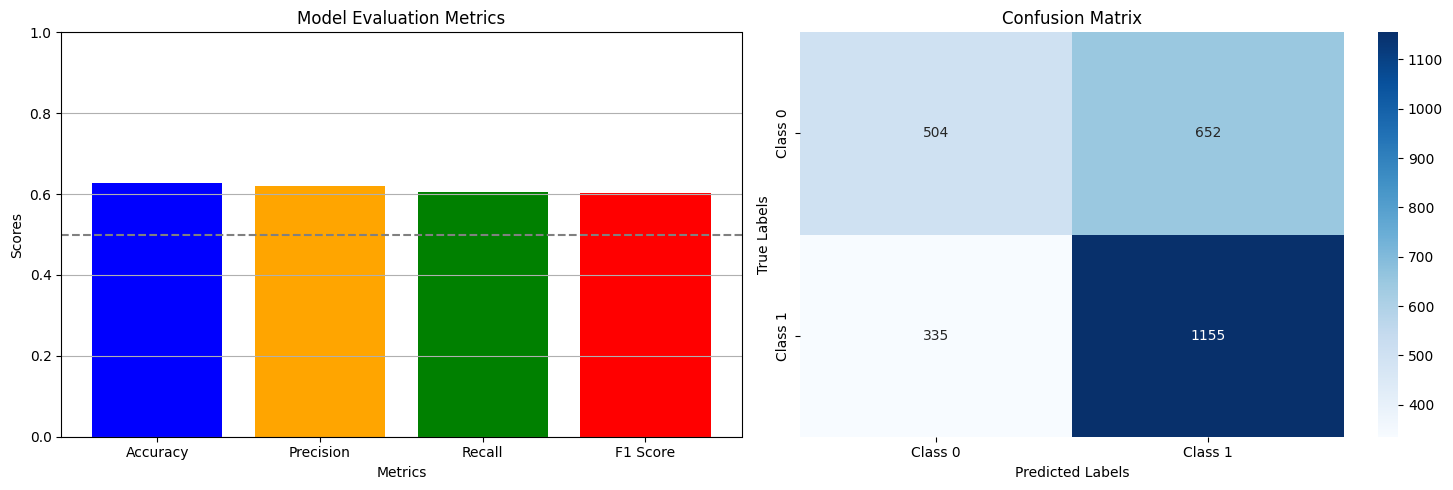

100%|██████████| 83/83 [00:15<00:00,  5.35it/s]


Epoch 2/5, Average Loss: 0.8392
Accuracy: 0.7831
Precision: 0.7964
Recall: 0.7656
F1 Score: 0.7704


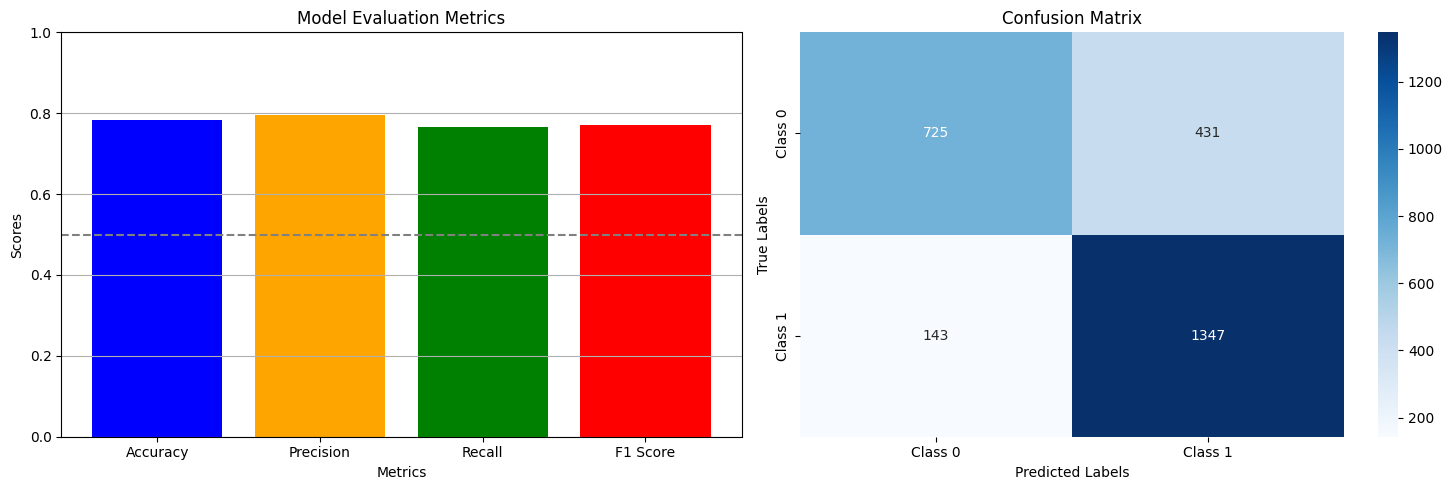

100%|██████████| 83/83 [00:15<00:00,  5.33it/s]


Epoch 3/5, Average Loss: 0.5350
Accuracy: 0.9505
Precision: 0.9492
Recall: 0.9503
F1 Score: 0.9498


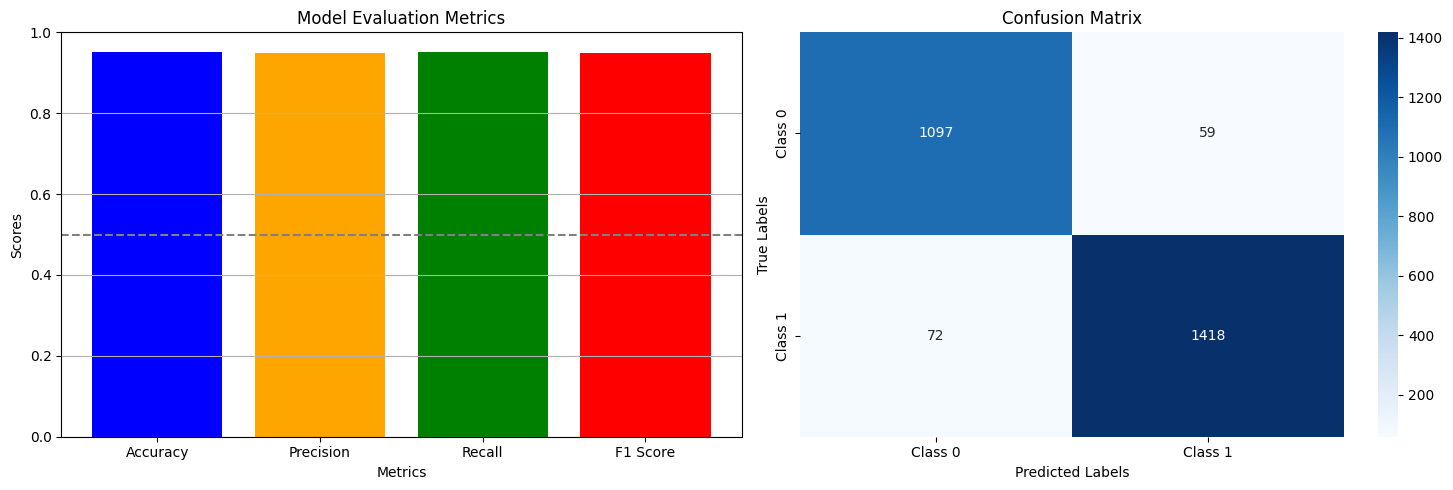

100%|██████████| 83/83 [00:15<00:00,  5.31it/s]


Epoch 4/5, Average Loss: 0.2464
Accuracy: 0.9834
Precision: 0.9837
Recall: 0.9825
F1 Score: 0.9831


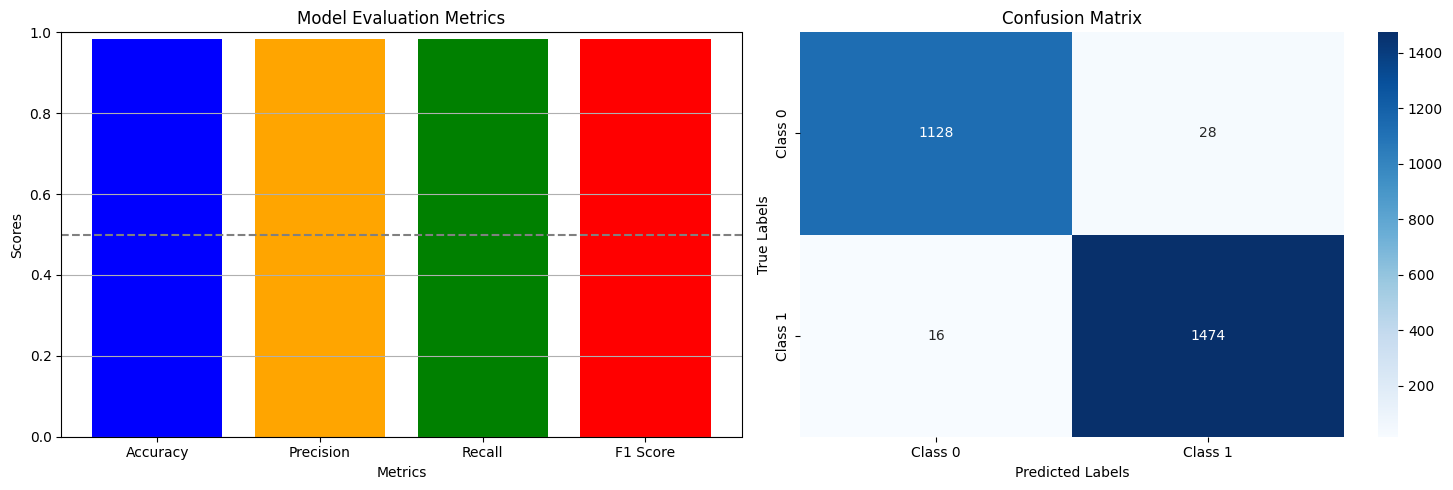

100%|██████████| 83/83 [00:15<00:00,  5.29it/s]


Epoch 5/5, Average Loss: 0.1237
Accuracy: 0.9974
Precision: 0.9973
Recall: 0.9974
F1 Score: 0.9973


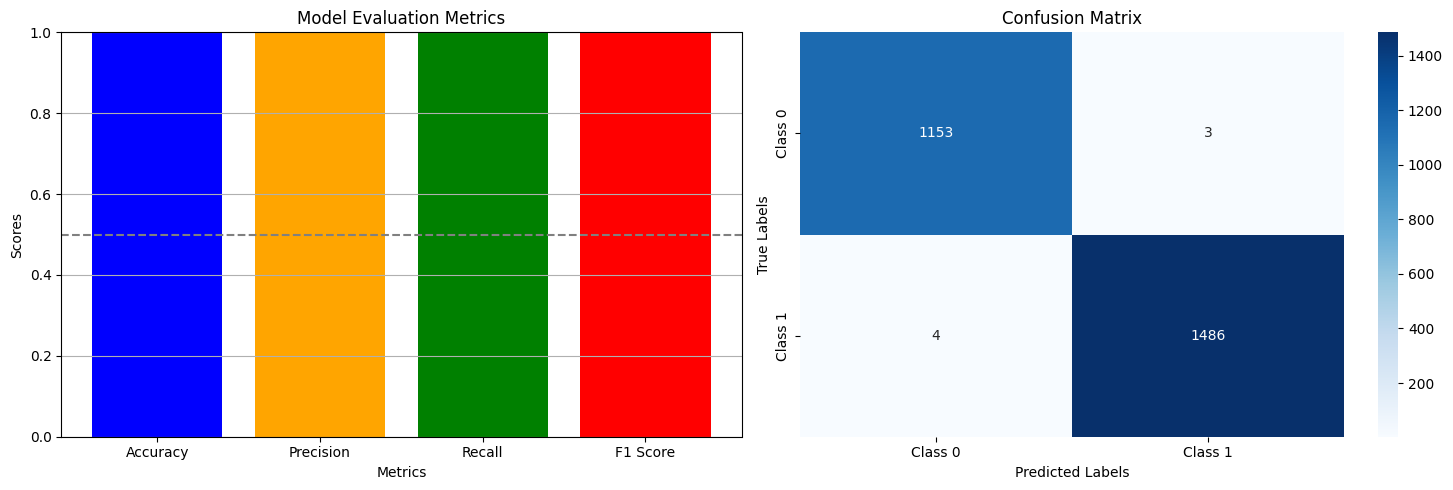

ggggggggggggggggggggggggggggg1
ggggggggggggggggggggggggggggg2
gggggggggggggggggggggggggggggසු​බෘ3

ව්‍යාකරණ පරීක්ෂණ ප්‍රතිඵල:
--------------------------------------------------------------------------------
මූල වාක්‍යය: දරුවෝ කලු ලෑල්ලේ විභාගය ලියා ඇත.
ව්‍යාකරණ නීතිය (3): ඇත/නැත ප්‍රත්‍යයේ යෙදීම-03
නිවැරදිද?: නැත
නිවැරදි කළ වාක්‍යය: දරුව​න් කලු ලෑල්ලේ විභාගය ලියා ඇත.
පණිවිඩය: කතෲ ලෙස ප්‍රාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්‍රියාවක්/කෘදන්තය​ක් වාක්‍යයේ ඇත්නම් ඇත/නැත ප්‍රත්‍යය සමඟ යෙදෙන ප්‍රාණවාචී බහුවචන කතෲ අනුක්​ත විය යුතුයි.
--------------------------------------------------------------------------------
{'original': 'දරුවෝ කලු ලෑල්ලේ විභාගය ලියා ඇත.', 'rule': 3, 'is_correct': False, 'corrected': 'දරුව\u200bන් කලු ලෑල්ලේ විභාගය ලියා ඇත.', 'message': 'කතෲ ලෙස ප්\u200dරාණවාචී බහුවචන පද ඇති විට, පූර්ව ක්\u200dරියාවක්/කෘදන්තය\u200bක් වාක්\u200dයයේ ඇත්නම් ඇත/නැත ප්\u200dරත්\u200dයය සමඟ යෙදෙන ප්\u200dරාණවාචී බහුවචන කතෲ අනුක්\u200bත විය යුතුයි.'}
True
වෝ
දරුවෝ
දරුව​න්
දරුවෝ කලු ලෑල්ලේ විභාගය ල

In [21]:
def get_rule_description(rule_num):
    """Returns the description of the grammar rule based on rule number"""
    rule_descriptions = {
        1: "ඇත/නැත ප්‍රත්‍යයේ යෙදීම-01",
        2: "ඇත/නැත ප්‍රත්‍යයේ යෙදීම-02",
        3: "ඇත/නැත ප්‍රත්‍යයේ යෙදීම-03",
        4: "දිවිත්ව උක්තයේ යෙදීම",
        5: "සන්ශය අර්තයේ ක්‍රියාවල යෙදීම"
    }
    return rule_descriptions.get(rule_num, "නොදන්නා නීතිය")

def main():
    # Initialize model
    base_model = AutoModel.from_pretrained('NLPC-UOM/SinBERT-small')
    model = SinhalaGrammarChecker(base_model)
    
    # Train model
    train_model(model, train_dataloader, test_dataloader, EPOCHS)
    
    # Example usage
    
    cleaned_text = clean_sinhala_text_advanced("දරුවෝ කලු ලෑල්ලේ විභාගය ලියා ඇත.")
    test_sentence = cleaned_text
    result = correct_grammar(model, tokenizer, test_sentence, 3)
    
    # Print results
    print("\nව්‍යාකරණ පරීක්ෂණ ප්‍රතිඵල:")
    print("-" * 80)
    print(f"මූල වාක්‍යය: {result['original']}")
    print(f"ව්‍යාකරණ නීතිය ({result['rule']}): {get_rule_description(result['rule'])}")
    print(f"නිවැරදිද?: {'ඔව්' if result['is_correct'] else 'නැත'}")
    if not result['is_correct']:
        print(f"නිවැරදි කළ වාක්‍යය: {result['corrected']}")
        print(f"පණිවිඩය: {result['message']}")
    print("-" * 80)
    print(result)
    print(is_purwa_kriya(test_sentence))
    print(check_first_word_ending(test_sentence))
    print(convert_n_to_o(test_sentence))
    print(convert_o_to_n(test_sentence))
    print(test_sentence)
    print(cleaned_text)
    print("-" * 80)


#...............................................................................................
    

# Initialize the grammar checker with API key
    API_KEY = "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"

   # if not result['is_correct']:
    grammar_checker = SinhalaGrammarCheckerWithLlma(API_KEY)
    
        # Example usage
    #test_sentences = [
     #       "ශිල්පීන් කලාකරුවෝ වන්නේ​ය.",
            # Add more test sentences here
      #  ]
    
   # for sentence in test_sentences:
    result2 = grammar_checker.check_grammar(test_sentence,5)
    print("\n" + "@"*50)
    print(result2)
    print("%"*50)
        



    sent = extract_correct_sentence(result2)
    print(sent)
    last_word = sent.split()[-1]
    #print(last_word)

    ss = result['corrected']
    fst_word = ss.split()[0]
    
    print(fst_word)
    
    words1 = sent.split()
    final1 = sent.replace(words1[0], fst_word)
    print("නිවැරදි කළ වාක්‍යය After Llama Integration:")
    print(final1)
    
    print("\n" + "@"*50)
    
    #words2 = ss.split()
    #final2 = ss.replace(words2[-1], last_word)
    #print(final2)



if __name__ == "__main__":
    main()